# 🎬 Movie Recommendation System — SVD Collaborative Filtering on MovieLens

This notebook builds a **collaborative filtering movie recommender** using **Singular Value Decomposition (SVD)** matrix factorization, implemented with the `scikit-surprise` library, trained on the **MovieLens "latest small"** dataset (100,836 ratings from 610 users across 9,724 rated movies).

**What this notebook covers, end to end:**
1. Loading and validating the four raw MovieLens CSV files (`movies`, `ratings`, `tags`, `links`).
2. Auditing and resolving a handful of duplicate movie IDs against external IMDb/TMDb identifiers.
3. Exploratory Data Analysis (EDA) on rating and user behavior patterns.
4. Training a baseline SVD model and evaluating it with 5-fold cross-validation.
5. Tuning hyperparameters with `GridSearchCV`.
6. Refitting the tuned model on the full dataset for production use.
7. Generating personalized top-10 recommendations for a target user.
8. Saving the trained model to disk with `joblib`.

## 1. Environment Setup

The next three cells install the required package, import all libraries used (and some carried over from a shared project template), and fix a random seed for reproducibility.

In [1]:
!pip install scikit-surprise pandas

### 1.1 Import Libraries

Most of the libraries below (`scikit-learn` classifiers, `xgboost`, `lightgbm`, `catboost`, `imbalanced-learn`, `optuna`, `lime`) are imported from a shared project template but are **not actually used** anywhere in this notebook's pipeline. The only libraries this SVD recommender genuinely depends on are `pandas`, `numpy`, `matplotlib`/`seaborn` for visualization, and `surprise` for the collaborative filtering model itself.

In [2]:
# =========================================================
# LIBRARY CONFIGURATION
# =========================================================

# 1. STANDARD UTILITIES AND CONFIGURATION
import os
import copy
import time
import warnings
import joblib

# Suppression of execution warnings to maintain a clean terminal output
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

# 2. CORE DATA MANIPULATION AND VISUALIZATION
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

# 3. RECOMMENDER SYSTEM FRAMEWORK (SURPRISE)
from surprise import AlgoBase, Dataset, Reader, SVD, accuracy
# Aliasing to prevent namespace collisions with scikit-learn modules
from surprise.model_selection import (
    train_test_split as surprise_train_test_split,
    cross_validate as surprise_cross_validate,
    GridSearchCV as surprise_GridSearchCV
)

# 4. DATA PREPROCESSING, PIPELINES, AND RESAMPLING TECHNIQUES
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    label_binarize,
    PowerTransformer,
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    TargetEncoder
)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTENC, SMOTEN, SMOTE, KMeansSMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

# 5. VALIDATION FRAMEWORKS AND PERFORMANCE METRICS
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)
import optuna
from sklearn.metrics import (
    # Classification Metrics
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    # Regression Metrics
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 6. ESTIMATORS AND MACHINE LEARNING ALGORITHMS
# Linear and Distance-based Models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC

# Tree-based Models and Ensembles
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingRegressor
)

# Naive Bayes Models
from sklearn.naive_bayes import BernoulliNB, GaussianNB

# Advanced Gradient Boosting Implementations
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier

# 7. MODEL INTERPRETABILITY AND EXPLANATION TOOLS
import lime
import lime.lime_tabular

### 1.2 Fix the Random Seed

A single `random_state` value is defined once here and reused everywhere a random operation happens (train-test split, model initialization, grid search), so the entire notebook produces the same results on every rerun.

In [3]:
random_state=42

## 2. Data Loading & Validation

The MovieLens dataset ships as four separate CSV files. The cell below loops through all of them and runs the same diagnostic routine on each one: a preview of the data (head/tail/random sample), column types, summary statistics, a missing-value check, a duplicated-row check, and a per-column unique-value breakdown. Running this before doing anything else makes it possible to catch structural issues (missing files, empty data, unexpected columns) early.

In [4]:
# Target directory paths for the MovieLens CSV datasets
file_paths = [
    "/kaggle/input/datasets/grouplens/movielens-latest-small/movies.csv",
    "/kaggle/input/datasets/grouplens/movielens-latest-small/ratings.csv",
    "/kaggle/input/datasets/grouplens/movielens-latest-small/tags.csv",
    "/kaggle/input/datasets/grouplens/movielens-latest-small/links.csv"
]

# Data ingestion and validation block
try:
    for file_path in file_paths:
        print("\n" + "="*70)
        print(f"📂 [LOADING] {os.path.basename(file_path)}")
        print("="*70)
        
        if os.path.exists(file_path):
            # Pandas DataFrame representation of the parsed CSV file
            df = pd.read_csv(file_path)
            
            if not df.empty:
                # ==============================================================================
                # 0. DATASET PREVIEW
                # ==============================================================================
                print()
                print("=" * 70)
                print(" DATASET PREVIEW ".center(70, "="))
                print("=" * 70)
                print("-> HEAD (Top 5 Rows):")
                display(df.head())

                print("\n-> TAIL (Bottom 5 Rows):")
                display(df.tail())

                print("\n-> SAMPLE (Random 5 Rows):")
                display(df.sample(5))

                print("-" * 70)
                print(f"Total Rows    : {df.shape[0]}")
                print(f"Total Columns : {df.shape[1]}")
                print("=" * 70 + "\n")


                # ==============================================================================
                # 1. DATASET BASIC INFORMATION
                # ==============================================================================
                print("=" * 70)
                print(" DATASET INFORMATION ".center(70, "="))
                print("=" * 70)
                display(df.info())
                print("\n")


                # ==============================================================================
                # 2. STATISTICAL DESCRIPTION
                # ==============================================================================
                print("=" * 70)
                print(" STATISTICAL DESCRIPTION ".center(70, "="))
                print("=" * 70)
                display(df.describe(include="all"))
                print("\n")


                # ==============================================================================
                # 3. MISSING VALUES CHECK
                # ==============================================================================
                print("=" * 70)
                print(" MISSING VALUES ".center(70, "="))
                print("=" * 70)

                null_counts = df.isnull().sum()
                display(null_counts)

                if null_counts.sum() > 0:
                    display(df[df.isnull().any(axis=1)])
                else:
                    print("No missing values found.")
                print("\n")


                # ==============================================================================
                # 4. DUPLICATED ROWS CHECK
                # ==============================================================================
                print("=" * 70)
                print(" DUPLICATED ROWS ".center(70, "="))
                print("=" * 70)

                duplicated_num = df.duplicated().sum()
                print(f"Total duplicated rows found: {duplicated_num}")

                if duplicated_num > 0:
                    display(df[df.duplicated()])
                else:
                    print("No duplicated rows found.")
                print("\n")


                # ==============================================================================
                # 5. UNIQUE VALUES PER COLUMN
                # ==============================================================================
                print("=" * 70)
                print(" UNIQUE VALUES PER COLUMN ".center(70, "="))
                print("=" * 70)

                for column in df.columns:
                    unique_count = df[column].nunique()
                    col_type = df[column].dtype

                    print(f"🔹 Column: '{column}' | Type: {col_type} | Unique Values: {unique_count}")

                    # Display unique values safely based on count
                    if unique_count <= 20:
                        print(f"   Values : {df[column].unique()}")
                    else:
                        print(f"   Values : {df[column].unique()[:5]} ... [Showing first 5]")

                    # Detail distributions specifically for Categorical data
                    if col_type == "object":
                        col_count = df[column].value_counts()
                        if len(col_count) <= 10:
                            print(f"   {col_count.to_string().replace(chr(10), chr(10) + '   ')}")
                        else:
                            print("\n   --- Value Counts ---")
                            print(f"   {col_count[:5].to_string().replace(chr(10), chr(10) + '   ')}")
                    else:
                        print("\n   --- Numeric Column ---")

                    print("=" * 70)
            else:
                print("⚠️ [WARNING] Dataset loaded successfully but contains no data records.")
        else:
            raise ValueError(f"🚨 [DATA ERROR] File not found at path: {file_path}")

# Exception handler for completely empty CSV file structures
except pd.errors.EmptyDataError:
    print("\n❌ [DATA ERROR]: A target CSV file is completely empty.")
    
# Fallback exception handler for generalized critical failures
except Exception as e:
    print(f"\n❌ [CRITICAL FAILURE]: {e}")


📂 [LOADING] movies.csv

========================== DATASET PREVIEW ===========================
-> HEAD (Top 5 Rows):


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



-> TAIL (Bottom 5 Rows):


,movieId,title,genres
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
9741,193609,Andrew Dice Clay: Dice Rules (1991),Comedy



-> SAMPLE (Random 5 Rows):


...

,movieId,imdbId,tmdbId
count,9742.000000,9.742000e+03,9734.000000
mean,42200.353623,6.771839e+05,55162.123793
std,52160.494854,1.107228e+06,93653.481487
min,1.000000,4.170000e+02,2.000000
25%,3248.250000,9.518075e+04,9665.500000
50%,7300.000000,1.672605e+05,16529.000000
75%,76232.000000,8.055685e+05,44205.750000
max,193609.000000,8.391976e+06,525662.000000




=========================== MISSING VALUES ===========================


movieId    0
imdbId     0
tmdbId     8
dtype: int64

,movieId,imdbId,tmdbId
624,791,113610,NaN
843,1107,102336,NaN
2141,2851,81454,NaN
3027,4051,56600,NaN
5532,26587,92337,NaN
5854,32600,377059,NaN
6059,40697,105946,NaN
7382,79299,874957,NaN




========================== DUPLICATED ROWS ===========================
Total duplicated rows found: 0
No duplicated rows found.


====================== UNIQUE VALUES PER COLUMN ======================
🔹 Column: 'movieId' | Type: int64 | Unique Values: 9742
   Values : [1 2 3 4 5] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'imdbId' | Type: int64 | Unique Values: 9742
   Values : [114709 113497 113228 114885 113041] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'tmdbId' | Type: float64 | Unique Values: 9733
   Values : [  862.  8844. 15602. 31357. 11862.] ... [Showing first 5]

   --- Numeric Column ---


### 2.1 Load Each Dataset into Its Own DataFrame

With the diagnostics confirming the files are readable and well-formed, each CSV is now loaded into its own dedicated DataFrame (`movies_df`, `ratings_df`, `tags_df`, `links_df`) for the rest of the notebook to work with.

In [5]:
# Load the MovieLens datasets into Pandas DataFrames
movies_df = pd.read_csv("/kaggle/input/datasets/grouplens/movielens-latest-small/movies.csv")
ratings_df = pd.read_csv("/kaggle/input/datasets/grouplens/movielens-latest-small/ratings.csv")
tags_df = pd.read_csv("/kaggle/input/datasets/grouplens/movielens-latest-small/tags.csv")
links_df = pd.read_csv("/kaggle/input/datasets/grouplens/movielens-latest-small/links.csv")

## 3. Data Cleaning — Duplicate Movie ID Resolution

Before merging or training on this data, it's worth checking whether any movie title maps to more than one `movieId`. If the same film was accidentally recorded under two different IDs during data collection, that would split its rating signal in two and understate its true popularity to any model trained on it. The cell below flags every title that has more than one associated ID.

In [6]:
# Aggregation to isolate duplicate entries by counting unique IDs per movie title
id_counts_by_title = movies_df.groupby("title")["movieId"].nunique().reset_index(name="id_count")

# Filters explicitly for titles mapped to multiple distinct IDs
duplicate_titles = id_counts_by_title[id_counts_by_title["id_count"] > 1].sort_values(by="id_count", ascending=False)

# Terminal UI header for duplicate detection results
print("\n" + "=" * 70)
print(" TITLES WITH MULTIPLE MOVIE IDs ".center(70, "="))
print("=" * 70)

# Conditional display handling based on anomaly presence
if len(duplicate_titles) > 0:
    display(duplicate_titles)
else:
    print("✅ [CLEAN] No duplicate movie titles found across the dataset.")
print("-" * 70 + "\n")


=================== TITLES WITH MULTIPLE MOVIE IDs ===================


,title,id_count
1939,Confessions of a Dangerous Mind (2002),2
2723,Emma (1996),2
2785,Eros (2004),2
7393,Saturn 3 (1980),2
9287,War of the Worlds (2005),2


----------------------------------------------------------------------



### 3.1 Cross-Reference Duplicates Against External IDs

A duplicated title alone isn't proof of a data error, since two genuinely different films (a remake, a different adaptation) can share the exact same title. To tell the two cases apart, each duplicated title's records are joined against `links_df`, which carries their external IMDb and TMDb identifiers. Comparing genres and external IDs side by side makes it possible to judge, case by case, whether a duplicate is a real linking error or a legitimately distinct movie.

In [7]:
# Extraction of all duplicate title records to verify consistency across external databases (IMDb/TMDb)
duplicate_title_records = movies_df[movies_df.duplicated("title", keep=False)].sort_values(by="title")

# Integration with external link identifiers for deeper anomaly resolution
merged_duplicate_data = duplicate_title_records.merge(links_df, on="movieId", how="left")

# Terminal UI header for cross-reference anomaly detection results
print("\n" + "=" * 70)
print(" DUPLICATE TITLES & EXTERNAL LINKS MATCHING ".center(70, "="))
print("=" * 70)

# Conditional display handling based on anomaly presence
if len(merged_duplicate_data) > 0:
    print(f"Total anomalous records to review : {len(merged_duplicate_data)}")
    print("-" * 70)
    display(merged_duplicate_data[['movieId', 'title', 'genres', 'imdbId', 'tmdbId']])
else:
    print("✅ [CLEAN] No duplicate movie titles require external cross-referencing.")
print("-" * 70 + "\n")


============= DUPLICATE TITLES & EXTERNAL LINKS MATCHING =============
Total anomalous records to review : 10
----------------------------------------------------------------------


,movieId,title,genres,imdbId,tmdbId
0,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller,290538,4912.0
1,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller,270288,4912.0
2,838,Emma (1996),Comedy|Drama|Romance,116191,3573.0
3,26958,Emma (1996),Romance,118308,12254.0
4,32600,Eros (2004),Drama,377059,NaN
5,147002,Eros (2004),Drama|Romance,343663,39850.0
6,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller,81454,NaN
7,168358,Saturn 3 (1980),Sci-Fi|Thriller,79285,19761.0
8,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller,407304,74.0
9,64997,War of the Worlds (2005),Action|Sci-Fi,449040,34812.0


----------------------------------------------------------------------



### 3.2 Resolve and Consolidate Duplicate IDs

Based on the manual review above, five duplicated titles were found in total. Three of them (*Confessions of a Dangerous Mind*, *Eros*, *Saturn 3*) have consistent genres across their duplicate rows, and their missing `tmdbId` values turned out to simply be a linking failure during data collection rather than a sign of a different film, so their IDs are safely merged into one canonical ID each. The other two (*Emma*, *War of the Worlds*) have conflicting genres and distinct TMDb IDs, confirming they're genuinely different productions sharing a title (for example, a theatrical release versus a TV movie), so they are deliberately **left unmerged** to avoid corrupting the data. The mapping below is applied across `ratings_df`, `tags_df`, and `movies_df` so every dataset stays consistent.

In [8]:
# =========================================================
# DUPLICATE ID CONSOLIDATION
# =========================================================

# CRITICAL DATA VALIDATION: 
# Anomalies are resolved based on genre consistency and external ID matching.
# 
# 1. EXCLUDED FROM MERGING (Distinct Productions):
#    - "Emma" & "War of the Worlds": Despite sharing titles and release years, they have 
#      conflicting genres and distinct TMDB IDs. This confirms they are separate adaptations 
#      (e.g., theatrical vs. TV movie, or blockbuster vs. indie). Merging would corrupt data.
#
# 2. INCLUDED IN MERGING (Genuine Data-Linking Errors):
#    - "Confessions of a Dangerous Mind", "Eros", & "Saturn 3": Genres are highly consistent. 
#      The presence of NaN in tmdbId for some of these rows is simply a failure to link 
#      to the external TMDB database during data collection, not an indicator of a different film. 
#      These are safe to consolidate.

# Dictionary mapping obsolete or duplicate movie IDs to their primary canonical IDs
duplicate_movie_mapping = {
    6003: 144606,    # Confessions of a Dangerous Mind
    # 26958: 838,    # Emma (DO NOT MERGE - Distinct adaptations with conflicting genres/TMDB IDs)
    32600: 147002,   # Eros (SAFE TO MERGE - NaN tmdbId is just a linking failure; genres match)
    168358: 2851,    # Saturn 3 (SAFE TO MERGE - NaN tmdbId is just a linking failure; genres match)
    # 64997: 34048   # War of the Worlds (DO NOT MERGE - Distinct adaptations with conflicting genres/TMDB IDs)
}

# Terminal UI header for the data consolidation process
print("\n" + "=" * 70)
print(" RESOLVING DUPLICATE MOVIE IDs ".center(70, "="))
print("=" * 70)

# Standardize foreign keys in the relational datasets using the canonical mapping
ratings_df["movieId"] = ratings_df["movieId"].replace(duplicate_movie_mapping)
tags_df["movieId"] = tags_df["movieId"].replace(duplicate_movie_mapping)

# Standardize the primary key in the movies dataset and drop redundant title records
movies_df["movieId"] = movies_df["movieId"].replace(duplicate_movie_mapping)
movies_df = movies_df.drop_duplicates(subset=["movieId"], keep="first")

# Execution confirmation output
print(f"✅ [SUCCESS] Consolidated {len(duplicate_movie_mapping)} duplicate titles across all datasets.")
print("-" * 70 + "\n")


=================== RESOLVING DUPLICATE MOVIE IDs ====================
✅ [SUCCESS] Consolidated 3 duplicate titles across all datasets.
----------------------------------------------------------------------



## 4. Merge Ratings with Movie Metadata

With duplicate IDs resolved, the ratings and movie metadata can now be safely joined into a single working DataFrame, `combined_df`, which the rest of the notebook (EDA and modeling) will use.

In [9]:
# Rename the timestamp column to provide clearer context
ratings_df = ratings_df.rename(columns={"timestamp": "rating_timestamp"})

# Perform a left join to enrich the ratings data with movie details
combined_df = ratings_df.merge(
    movies_df,
    on="movieId",
    how="left"
)

# Display the first few rows of the merged dataset
display(combined_df.head())

,userId,movieId,rating,rating_timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


### 4.1 Re-Verify No Duplicate IDs Remain

As a sanity check, the same duplicate-detection logic from Section 3 is run again on the newly merged combined_df. This confirms the ID consolidation worked. Any title still showing up as a duplicate at this point should only be one of the genuinely distinct movies deliberately left unmerged (same title, same release era, but different productions), not a leftover data-linking error.

In [10]:
# Aggregation to isolate duplicate entries by counting unique IDs per movie title
id_counts_by_title = combined_df.groupby("title")["movieId"].nunique().reset_index(name="id_count")

# Filters explicitly for titles mapped to multiple distinct IDs
duplicate_titles = id_counts_by_title[id_counts_by_title["id_count"] > 1].sort_values(by="id_count", ascending=False)

# Terminal UI header for duplicate detection results
print("\n" + "=" * 70)
print(" TITLES WITH MULTIPLE MOVIE IDs ".center(70, "="))
print("=" * 70)

# Conditional display handling based on anomaly presence
if len(duplicate_titles) > 0:
    display(duplicate_titles)
else:
    print("✅ [CLEAN] No duplicate movie titles found across the dataset.")
print("-" * 70 + "\n")


=================== TITLES WITH MULTIPLE MOVIE IDs ===================


,title,id_count
2718,Emma (1996),2
9269,War of the Worlds (2005),2


----------------------------------------------------------------------



### 4.2 Combined Dataset Overview

The same full diagnostic routine used on the raw CSVs in Section 2 is run one more time, now on the merged `combined_df`, to confirm the join didn't introduce any unexpected nulls, duplicate rows, or type issues before moving on to analysis and modeling.

In [11]:
# ==============================================================================
# 0. DATASET PREVIEW
# ==============================================================================
print("=" * 70)
print(" DATASET PREVIEW ".center(70, "="))
print("=" * 70)
print("-> HEAD (Top 5 Rows):")
display(combined_df.head())

print("\n-> TAIL (Bottom 5 Rows):")
display(combined_df.tail())

print("\n-> SAMPLE (Random 5 Rows):")
display(combined_df.sample(5))

print("-" * 70)
print(f"Total Rows    : {combined_df.shape[0]}")
print(f"Total Columns : {combined_df.shape[1]}")
print("=" * 70 + "\n")


# ==============================================================================
# 1. DATASET BASIC INFORMATION
# ==============================================================================
print("=" * 70)
print(" DATASET INFORMATION ".center(70, "="))
print("=" * 70)
display(combined_df.info())
print("\n")


# ==============================================================================
# 2. STATISTICAL DESCRIPTION
# ==============================================================================
print("=" * 70)
print(" STATISTICAL DESCRIPTION ".center(70, "="))
print("=" * 70)
display(combined_df.describe(include="all"))
print("\n")


# ==============================================================================
# 3. MISSING VALUES CHECK
# ==============================================================================
print("=" * 70)
print(" MISSING VALUES ".center(70, "="))
print("=" * 70)

null_counts = combined_df.isnull().sum()
display(null_counts)

if null_counts.sum() > 0:
    display(combined_df[combined_df.isnull().any(axis=1)])
else:
    print("No missing values found.")
print("\n")


# ==============================================================================
# 4. DUPLICATED ROWS CHECK
# ==============================================================================
print("=" * 70)
print(" DUPLICATED ROWS ".center(70, "="))
print("=" * 70)

duplicated_num = combined_df.duplicated().sum()
print(f"Total duplicated rows found: {duplicated_num}")

if duplicated_num > 0:
    display(combined_df[combined_df.duplicated()])
else:
    print("No duplicated rows found.")
print("\n")


# ==============================================================================
# 5. UNIQUE VALUES PER COLUMN
# ==============================================================================
print("=" * 70)
print(" UNIQUE VALUES PER COLUMN ".center(70, "="))
print("=" * 70)

for column in combined_df.columns:
    unique_count = combined_df[column].nunique()
    col_type = combined_df[column].dtype

    print(f"🔹 Column: '{column}' | Type: {col_type} | Unique Values: {unique_count}")

    # Display unique values safely based on count
    if unique_count <= 20:
        print(f"   Values : {combined_df[column].unique()}")
    else:
        print(f"   Values : {combined_df[column].unique()[:5]} ... [Showing first 5]")

    # Detail distributions specifically for Categorical data
    if col_type == "object":
        col_count = combined_df[column].value_counts()
        if len(col_count) <= 10:
            print(f"   {col_count.to_string().replace(chr(10), chr(10) + '   ')}")
        else:
            print("\n   --- Value Counts ---")
            print(f"   {col_count[:5].to_string().replace(chr(10), chr(10) + '   ')}")
    else:
        print("\n   --- Numeric Column ---")

    print("=" * 70)

========================== DATASET PREVIEW ===========================
-> HEAD (Top 5 Rows):


,userId,movieId,rating,rating_timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller



-> TAIL (Bottom 5 Rows):


,userId,movieId,rating,rating_timestamp,title,genres
100831,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller
100832,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller
100833,610,168250,5.0,1494273047,Get Out (2017),Horror
100834,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi
100835,610,170875,3.0,1493846415,The Fate of the Furious (2017),Action|Crime|Drama|Thriller



-> SAMPLE (Random 5 Rows):


...



====================== STATISTICAL DESCRIPTION =======================


,userId,movieId,rating,rating_timestamp,title,genres
count,100836.000000,100836.000000,100836.000000,1.008360e+05,100836,100836
unique,NaN,NaN,NaN,NaN,9719,951
top,NaN,NaN,NaN,NaN,Forrest Gump (1994),Comedy
freq,NaN,NaN,NaN,NaN,329,7196
mean,326.127564,19455.406988,3.501557,1.205946e+09,NaN,NaN
std,182.618491,35562.577975,1.042529,2.162610e+08,NaN,NaN
min,1.000000,1.000000,0.500000,8.281246e+08,NaN,NaN
25%,177.000000,1199.000000,3.000000,1.019124e+09,NaN,NaN
50%,325.000000,2991.000000,3.500000,1.186087e+09,NaN,NaN
75%,477.000000,8132.000000,4.000000,1.435994e+09,NaN,NaN




=========================== MISSING VALUES ===========================


userId              0
movieId             0
rating              0
rating_timestamp    0
title               0
genres              0
dtype: int64

No missing values found.


========================== DUPLICATED ROWS ===========================
Total duplicated rows found: 0
No duplicated rows found.


====================== UNIQUE VALUES PER COLUMN ======================
🔹 Column: 'userId' | Type: int64 | Unique Values: 610
   Values : [1 2 3 4 5] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'movieId' | Type: int64 | Unique Values: 9721
   Values : [ 1  3  6 47 50] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'rating' | Type: float64 | Unique Values: 10
   Values : [4.  5.  3.  2.  1.  4.5 3.5 2.5 0.5 1.5]

   --- Numeric Column ---
🔹 Column: 'rating_timestamp' | Type: int64 | Unique Values: 85043
   Values : [964982703 964981247 964982224 964983815 964982931] ... [Showing first 5]

   --- Numeric Column ---
🔹 Column: 'title' | Type: object | Unique Values: 9719
   Values : ['Toy Story (1995)' 'Grumpier Old Men (1995)' 'Heat (1995)'
 'Seven (a.k.a. Se7en) (1995)' 'Usual Suspects, The (1995)'] ... [Sho

## 5. Exploratory Data Analysis (EDA)

This section looks at rating and user behavior patterns before any modeling happens, to understand what kind of data the recommender will actually be learning from.

### 5.1 Rating Distribution

A histogram of every individual rating in the dataset, with the mean, median, and mode marked, to see how ratings are distributed across the 0.5–5.0 scale (for example, whether users tend to rate generously, critically, or mostly stick to round numbers like 3.0, 4.0, and 5.0).

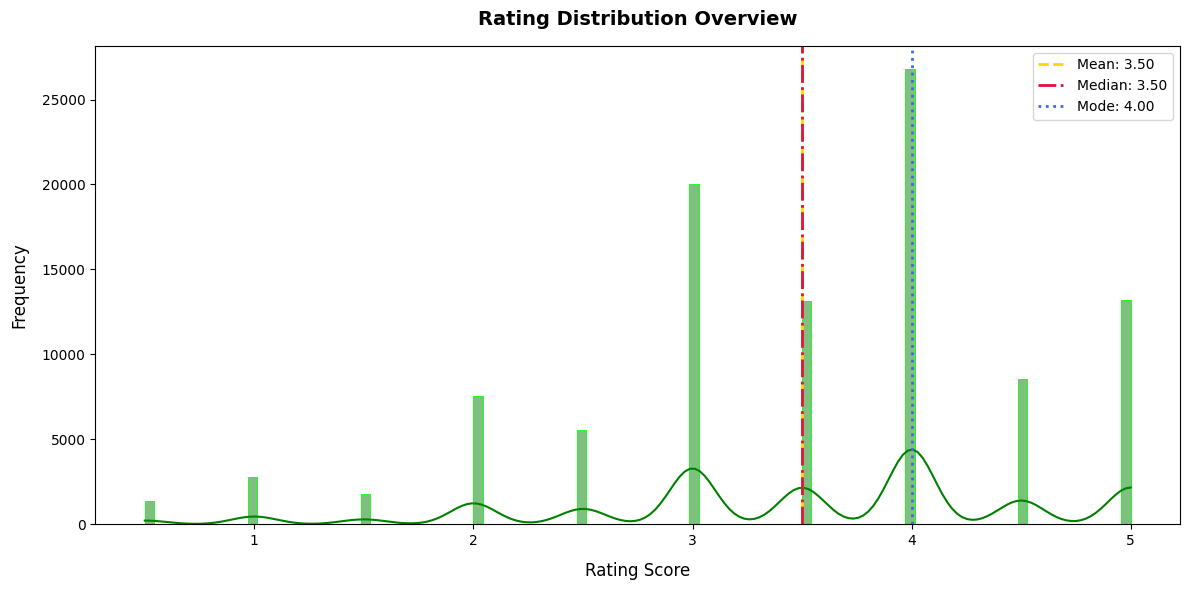

In [12]:
# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and histogram plot setup
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_df, x="rating", kde=True, color="green", edgecolor="lime")

# Central tendency metrics calculation
mean_val = combined_df["rating"].mean()
median_val = combined_df["rating"].median()
mode_val = combined_df["rating"].mode()[0]

# Vertical statistical markers
plt.axvline(mean_val, linestyle="--", color="gold", lw=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle="-.", color="crimson", lw=2, label=f"Median: {median_val:.2f}")
plt.axvline(mode_val, linestyle=":", color="royalblue", lw=2, label=f"Mode: {mode_val:.2f}")

# Plot typography and axis definitions
plt.title("Rating Distribution Overview", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Rating Score", fontsize=12, labelpad=10)
plt.ylabel("Frequency", fontsize=12, labelpad=10)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()

# Output file generation and rendering
file_path = f"{output_dir}/rating_distribution.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.2 User Activity Distribution

A histogram of how many ratings each individual user has submitted in total, to see whether rating activity is fairly even across users or dominated by a small number of very active raters.


============= USER ACTIVITY DISTRIBUTION (TOTAL RATINGS) =============


,total_ratings
userId,
1,232
2,29
3,39
4,216
5,44


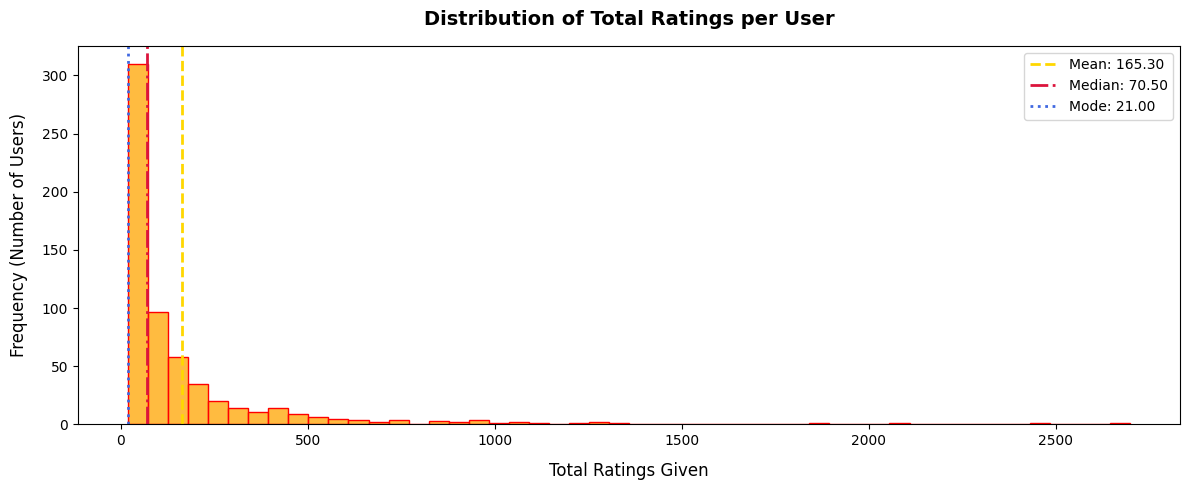

In [13]:
# Aggregation of rating frequencies per user to analyze user activity distribution
total_ratings_by_user = combined_df.groupby("userId").size()

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" USER ACTIVITY DISTRIBUTION (TOTAL RATINGS) ".center(70, "="))
print("=" * 70)
# Showing head() wrapped in a frame so it renders cleanly in the notebook
display(total_ratings_by_user.to_frame(name="total_ratings").head())

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and histogram plot setup
plt.figure(figsize=(12, 5))
sns.histplot(data=total_ratings_by_user, color="orange", edgecolor="red", bins=50)

# Central tendency metrics calculation (aligned with the plotted user activity data)
mean_val = total_ratings_by_user.mean()
median_val = total_ratings_by_user.median()
mode_val = total_ratings_by_user.mode()[0]

# Vertical statistical markers
plt.axvline(mean_val, linestyle="--", color="gold", lw=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle="-.", color="crimson", lw=2, label=f"Median: {median_val:.2f}")
plt.axvline(mode_val, linestyle=":", color="royalblue", lw=2, label=f"Mode: {mode_val:.2f}")

# Plot typography and axis definitions
plt.title("Distribution of Total Ratings per User", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Ratings Given", fontsize=12, labelpad=10)
plt.ylabel("Frequency (Number of Users)", fontsize=12, labelpad=10)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()

# Output file generation and rendering
file_path = f"{output_dir}/user_activity_distribution.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.3 Top 5 Most Active Users

The five users who have submitted the most ratings overall, shown as a bar chart.


================= TOP 5 USERS BY TOTAL RATINGS GIVEN =================


,userId,total_ratings
413,414,2698
598,599,2478
473,474,2108
447,448,1864
273,274,1346


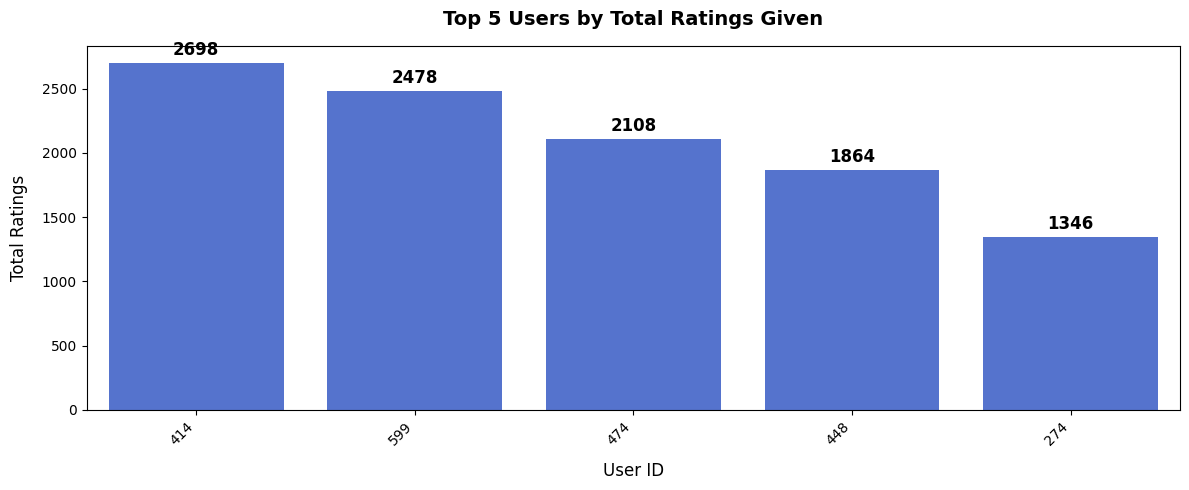

In [14]:
# Aggregation of rating frequencies per user to identify the most active reviewers
total_ratings_by_user = combined_df.groupby("userId").size().reset_index(name="total_ratings").sort_values(by="total_ratings", ascending=False).head(5)

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" TOP 5 USERS BY TOTAL RATINGS GIVEN ".center(70, "="))
print("=" * 70)
display(total_ratings_by_user)

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and bar plot setup
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=total_ratings_by_user, x="userId", y="total_ratings", color="royalblue", order=total_ratings_by_user["userId"])

# Plot typography and axis definitions
plt.title("Top 5 Users by Total Ratings Given", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("User ID", fontsize=12, labelpad=10)
plt.ylabel("Total Ratings", fontsize=12, labelpad=10)

# Value annotations for individual bar containers
for container in ax.containers:
    ax.bar_label(container, fmt="%g", padding=3, fontsize=12, fontweight="bold")

# Formatting adjustments and output file generation
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

file_path = f"{output_dir}/top_5_users_total_ratings.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.4 Top 5 Users by Average Rating

The five users whose average given rating is the highest, i.e. the most generous raters in the dataset (as opposed to the most active ones from the previous chart).


=================== TOP 5 USERS BY AVERAGE RATING ====================


,userId,average_rating
52,53,5.000000
250,251,4.869565
514,515,4.846154
24,25,4.807692
29,30,4.735294


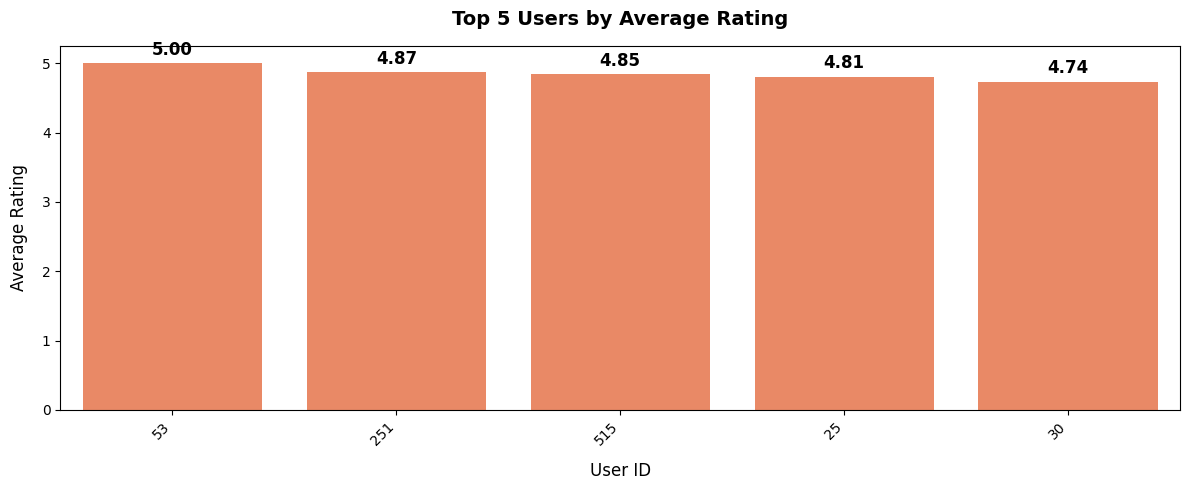

In [15]:
# Aggregation of average ratings per user to identify the most critical or generous reviewers
avg_rating_by_user = combined_df.groupby("userId")["rating"].mean().reset_index(name="average_rating").sort_values(by="average_rating", ascending=False).head(5)

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" TOP 5 USERS BY AVERAGE RATING ".center(70, "="))
print("=" * 70)
display(avg_rating_by_user)

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and bar plot setup
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=avg_rating_by_user, x="userId", y="average_rating", color="coral", order=avg_rating_by_user["userId"])

# Plot typography and axis definitions
plt.title("Top 5 Users by Average Rating", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("User ID", fontsize=12, labelpad=10)
plt.ylabel("Average Rating", fontsize=12, labelpad=10)

# Value annotations formatted to 2 decimal places for precise mean representation
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=12, fontweight="bold")

# Formatting adjustments and output file generation
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

file_path = f"{output_dir}/top_5_users_avg_rating.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.5 Movie Popularity Distribution

A histogram of the total number of ratings each movie has received. The x-axis is how many ratings a single movie got, and the y-axis is how many movies received that count. This shows whether movie popularity is spread evenly across the catalog or concentrated in a small number of widely-rated titles, which is the typical pattern for real-world rating data.


=========== MOVIE POPULARITY DISTRIBUTION (TOTAL RATINGS) ============


,,total_ratings
movieId,title,
1,Toy Story (1995),215
2,Jumanji (1995),110
3,Grumpier Old Men (1995),52
4,Waiting to Exhale (1995),7
5,Father of the Bride Part II (1995),49


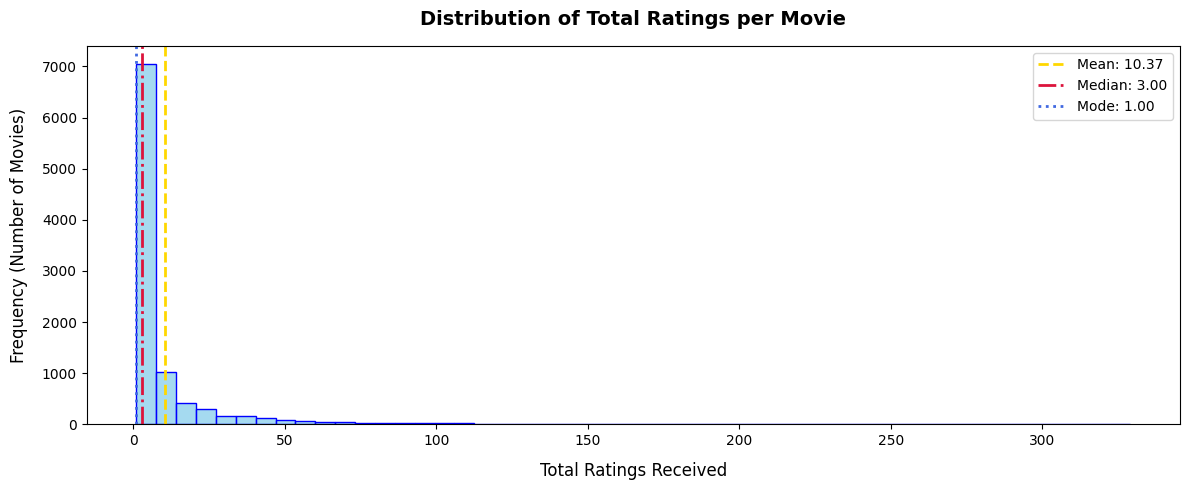

In [16]:
# Aggregation of rating frequencies per movie to analyze movie popularity distribution
total_ratings_by_movie = combined_df.groupby(["movieId", "title"]).size()

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" MOVIE POPULARITY DISTRIBUTION (TOTAL RATINGS) ".center(70, "="))
print("=" * 70)
# Showing head() wrapped in a frame so it renders cleanly in the notebook
display(total_ratings_by_movie.to_frame(name="total_ratings").head())

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and histogram plot setup
plt.figure(figsize=(12, 5))
sns.histplot(data=total_ratings_by_movie, color="skyblue", edgecolor="blue", bins=50)

# Central tendency metrics calculation (aligned with the plotted movie popularity data)
mean_val = total_ratings_by_movie.mean()
median_val = total_ratings_by_movie.median()
mode_val = total_ratings_by_movie.mode()[0]

# Vertical statistical markers
plt.axvline(mean_val, linestyle="--", color="gold", lw=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle="-.", color="crimson", lw=2, label=f"Median: {median_val:.2f}")
plt.axvline(mode_val, linestyle=":", color="royalblue", lw=2, label=f"Mode: {mode_val:.2f}")

# Plot typography and axis definitions
plt.title("Distribution of Total Ratings per Movie", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Ratings Received", fontsize=12, labelpad=10)
plt.ylabel("Frequency (Number of Movies)", fontsize=12, labelpad=10)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()

# Output file generation and rendering
file_path = f"{output_dir}/movie_popularity_distribution.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.6 Top 5 Most Popular Movies

The five movies with the highest total number of ratings received.


=================== TOP 5 MOVIES BY TOTAL RATINGS ====================


,movieId,title,total_ratings
314,356,Forrest Gump (1994),329
277,318,"Shawshank Redemption, The (1994)",317
257,296,Pulp Fiction (1994),307
510,593,"Silence of the Lambs, The (1991)",279
1938,2571,"Matrix, The (1999)",278


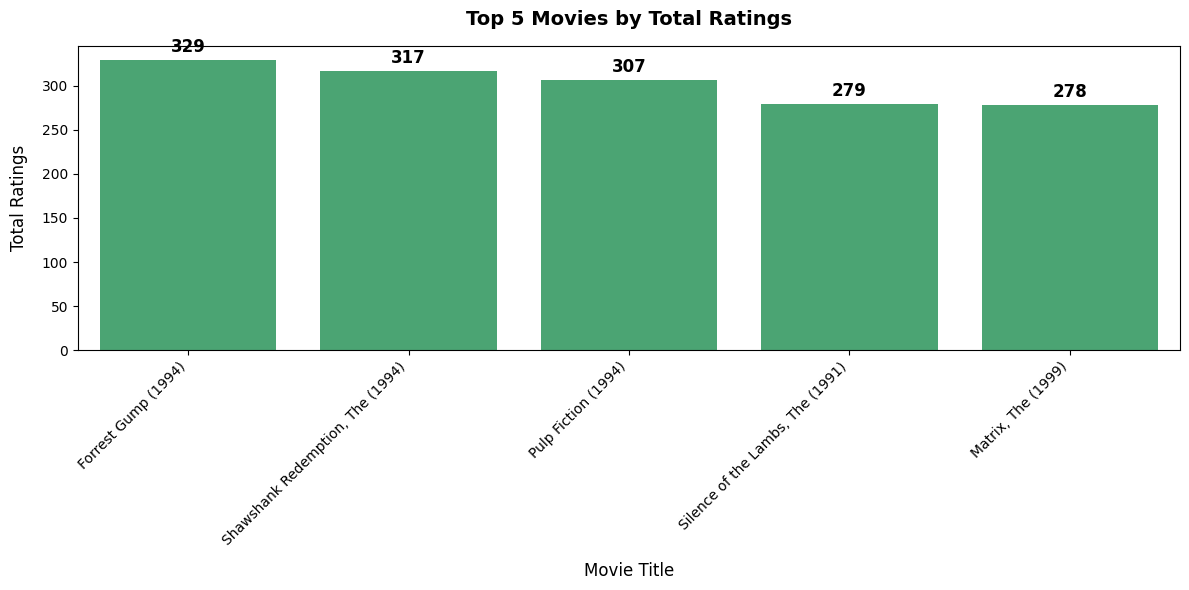

In [17]:
# Aggregation of rating frequencies per movie to identify the most popular titles
top_movies_by_rating_count = combined_df.groupby(["movieId", "title"]).size().reset_index(name="total_ratings").sort_values(by="total_ratings", ascending=False).head(5)

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" TOP 5 MOVIES BY TOTAL RATINGS ".center(70, "="))
print("=" * 70)
display(top_movies_by_rating_count)

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and bar plot setup
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_movies_by_rating_count, x="title", y="total_ratings", color="mediumseagreen", order=top_movies_by_rating_count["title"])

# Plot typography and axis definitions
plt.title("Top 5 Movies by Total Ratings", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Movie Title", fontsize=12, labelpad=10)
plt.ylabel("Total Ratings", fontsize=12, labelpad=10)

# Value annotations formatted as integers for count representation
for container in ax.containers:
    ax.bar_label(container, fmt="%g", padding=3, fontsize=12, fontweight="bold")

# Formatting adjustments and output file generation
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

file_path = f"{output_dir}/top_5_movies_total_ratings.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.7 Top 5 Highest-Rated Movies

The five movies with the highest average rating.


=================== TOP 5 MOVIES BY AVERAGE RATING ===================


,movieId,title,average_rating
3251,4402,Dr. Goldfoot and the Bikini Machine (1965),5.0
8087,100556,"Act of Killing, The (2012)",5.0
8095,100906,Maniac Cop 2 (1990),5.0
4103,5889,"Cruel Romance, A (Zhestokij Romans) (1984)",5.0
1005,1310,Hype! (1996),5.0


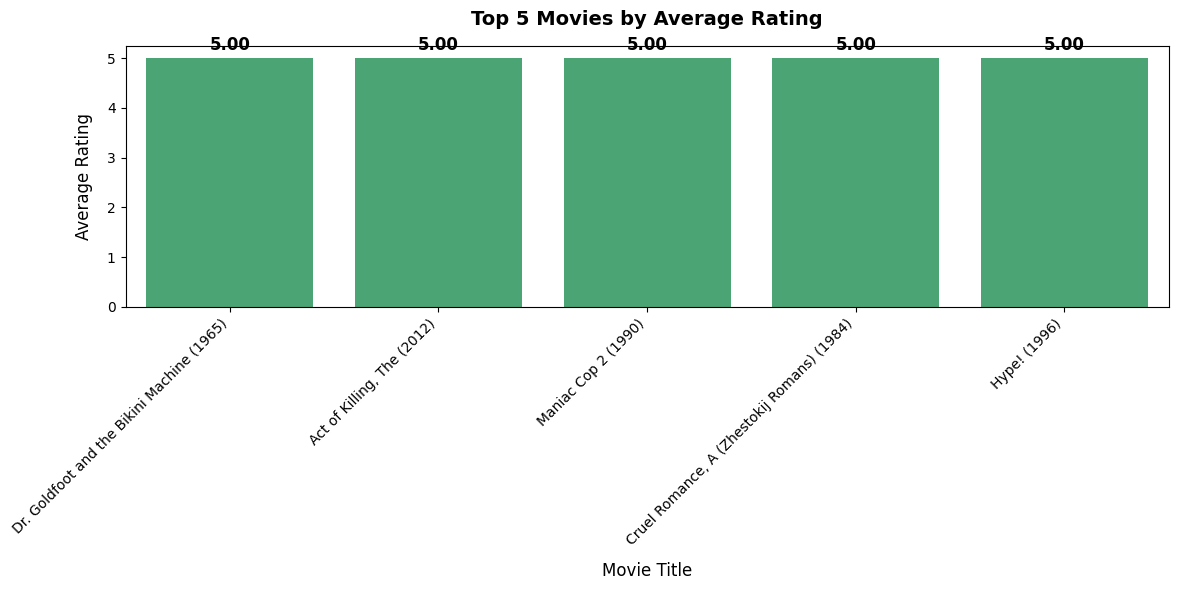

In [18]:
# Aggregation of average ratings per movie to identify the highest-rated titles
avg_rating_by_movie = combined_df.groupby(["movieId", "title"])["rating"].mean().reset_index(name="average_rating").sort_values(by="average_rating", ascending=False).head(5)

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" TOP 5 MOVIES BY AVERAGE RATING ".center(70, "="))
print("=" * 70)
display(avg_rating_by_movie)

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and bar plot setup
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=avg_rating_by_movie, x="title", y="average_rating", color="mediumseagreen", order=avg_rating_by_movie["title"])

# Plot typography and axis definitions
plt.title("Top 5 Movies by Average Rating", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Movie Title", fontsize=12, labelpad=10)
plt.ylabel("Average Rating", fontsize=12, labelpad=10)

# Value annotations formatted to 2 decimal places for precise mean representation
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=12, fontweight="bold")

# Formatting adjustments and output file generation
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

file_path = f"{output_dir}/top_5_movies_avg_rating.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### 5.8 User-Item Interaction Sparsity

The user-item matrix (`userId` x `movieId`, filled with ratings where they exist) is the structure any collaborative filtering model ultimately learns from. The heatmap below visualizes how much of that matrix is actually filled in versus empty.


==================== USER-ITEM INTERACTION MATRIX ====================


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------
Sparsity Level : 98.30%



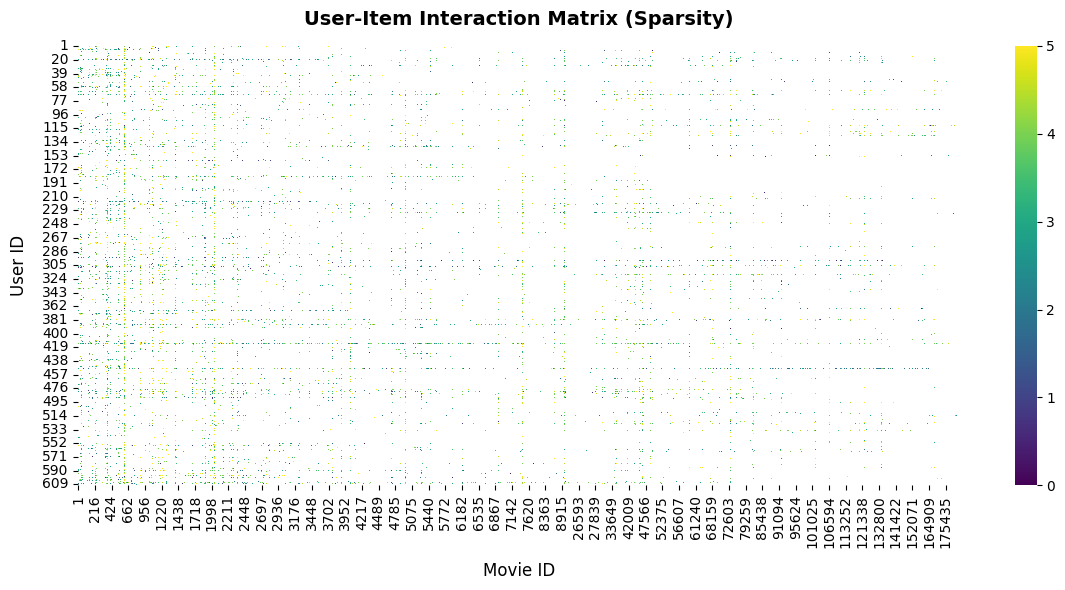

In [19]:
# Construction of the user-item interaction matrix to represent rating behaviors
sparsity_matrix = combined_df.pivot_table(index="userId", columns="movieId", values="rating")

# Calculation of the matrix sparsity ratio (percentage of missing interactions)
sparsity_percentage = (sparsity_matrix.isnull().sum().sum() / sparsity_matrix.size) * 100

# Terminal UI header for tabular data presentation
print("\n" + "=" * 70)
print(" USER-ITEM INTERACTION MATRIX ".center(70, "="))
print("=" * 70)
display(sparsity_matrix)
print("-" * 70)
print(f"Sparsity Level : {sparsity_percentage:.2f}%")
print("=" * 70 + "\n")

# Output directory definition for visualizations
output_dir = "output/visualizations"
os.makedirs(output_dir, exist_ok=True)

# Figure canvas and heatmap plot setup
plt.figure(figsize=(12, 6))

# Removed square=True and linewidth=0.5 to prevent dimensional squishing
sns.heatmap(sparsity_matrix, vmin=0, vmax=5, cmap="viridis")

# Plot typography and axis definitions
plt.title("User-Item Interaction Matrix (Sparsity)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Movie ID", fontsize=12, labelpad=10)
plt.ylabel("User ID", fontsize=12, labelpad=10)
plt.tight_layout()

# Output file generation
file_path = f"{output_dir}/sparsity_matrix_heatmap.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

**Result: the matrix is 98.30% sparse.** In other words, only about 1.7% of all possible user-movie pairs actually have a rating. This is the normal state for almost any real-world ratings dataset, not a flaw specific to this one, and it's exactly the kind of data a matrix factorization approach like SVD is designed to handle, since it learns latent factors that generalize to the unrated pairs rather than relying on a densely filled matrix.

## 6. Prepare Data for the `surprise` Library

The `surprise` library expects data in its own `Dataset` format rather than a raw pandas DataFrame. A `Reader` is defined with the dataset's actual rating scale (0.5 to 5.0), and `combined_df` is converted into a `surprise Dataset` object using only the three columns the model actually needs: `userId`, `movieId`, and `rating`.

In [20]:
reader = Reader(rating_scale=[combined_df.rating.min(), combined_df.rating.max()])

data = Dataset.load_from_df(
    combined_df[["userId", "movieId", "rating"]],
    reader
)

### 6.1 Train-Test Split

The dataset is split 80/20 into a training set and a held-out test set, using the fixed `random_state` for reproducibility. The training set is what the model will actually learn from; the test set is kept aside purely for evaluating how well the model generalizes to ratings it has never seen.

In [21]:
# Partitioning the dataset into training and testing subsets for validation
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=random_state)

# Terminal UI header for dataset split statistics
print("\n" + "=" * 70)
print(" SURPRISE TRAIN-TEST SPLIT SUMMARY ".center(70, "="))
print("=" * 70)

# Extracting dimensions safely based on Surprise object structures
print(f"Training Set Entities : {trainset.n_users} users | {trainset.n_items} items")
print(f"Training Set Ratings  : {trainset.n_ratings} records")
print(f"Testing Set Ratings   : {len(testset)} records")
print("-" * 70 + "\n")


================= SURPRISE TRAIN-TEST SPLIT SUMMARY ==================
Training Set Entities : 610 users | 8926 items
Training Set Ratings  : 80668 records
Testing Set Ratings   : 20168 records
----------------------------------------------------------------------



**Result:** the training split contains ratings drawn from all 610 users, covering the vast majority of the 9,721 rated movies present in the cleaned dataset, while the remaining 20% of ratings are held out as the test set used for evaluation later in the notebook.

## 7. Baseline SVD Model

### 7.1 Initialize the Model

A baseline `SVD` model is instantiated with commonly-used default-style hyperparameters (`n_factors=100`, `n_epochs=20`, `lr_all=0.005`, `reg_all=0.02`) before any tuning happens, so its performance can later be compared against a tuned version to see whether tuning is actually worth the extra computation.

In [22]:
# Terminal UI header for model configuration
print("\n" + "=" * 70)
print(" INITIALIZING SVD MODEL ".center(70, "="))
print("=" * 70)

# Initialize the SVD (Singular Value Decomposition) algorithm with baseline hyperparameters
model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=random_state
)

print("SVD model instantiated successfully with baseline parameters.")
print("-" * 70 + "\n")


======================= INITIALIZING SVD MODEL =======================
SVD model instantiated successfully with baseline parameters.
----------------------------------------------------------------------



### 7.2 5-Fold Cross-Validation

Before committing to a single train-test split, the baseline model is evaluated with 5-fold cross-validation across the whole dataset, reporting RMSE, MAE, and FCP (Fraction of Concordant Pairs) for each fold. This gives a more robust estimate of the model's real-world performance than a single split would, since it averages results across five different ways of partitioning the data.

In [23]:
# Terminal UI header for the cross validation process
print("\n" + "=" * 70)
print(" 5 FOLD CROSS VALIDATION SVD MODEL ".center(70, "="))
print("=" * 70)
print("Initiating cross validation This may take a while\n")

# Execute cross validation with execution time tracking
start_time = time.time()
cv_results = surprise_cross_validate(
    model,
    data,
    measures=["RMSE", "MAE", "FCP"],
    cv=5,
    verbose=True
)
end_time = time.time()

# Time conversion for human readable output
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

# Safe calculation of mean and standard deviation for evaluation metrics
mean_rmse = np.mean(cv_results.get("test_rmse", [0]))
std_rmse = np.std(cv_results.get("test_rmse", [0]))

mean_mae = np.mean(cv_results.get("test_mae", [0]))
std_mae = np.std(cv_results.get("test_mae", [0]))

mean_fcp = np.mean(cv_results.get("test_fcp", [0]))
std_fcp = np.std(cv_results.get("test_fcp", [0]))

# Execution confirmation and formatted metrics output
print(f"\n✅ SUCCESS Cross validation completed in {minutes}m {seconds:.2f}s\n")
print("=" * 70)
print(" CROSS VALIDATION RESULTS ".center(70, "="))
print("=" * 70)
print(f"Average RMSE {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"Average MAE  {mean_mae:.4f} ± {std_mae:.4f}")
print(f"Average FCP  {mean_fcp:.4f} ± {std_fcp:.4f}")
print("=" * 70 + "\n")


================= 5 FOLD CROSS VALIDATION SVD MODEL ==================
Initiating cross validation This may take a while

Evaluating RMSE, MAE, FCP of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8680  0.8751  0.8852  0.8677  0.8674  0.8727  0.0069  
MAE (testset)     0.6669  0.6728  0.6784  0.6680  0.6680  0.6708  0.0043  
FCP (testset)     0.6621  0.6621  0.6542  0.6580  0.6617  0.6596  0.0031  
Fit time          1.06    1.07    1.07    1.08    1.10    1.08    0.01    
Test time         0.10    0.31    0.10    0.10    0.29    0.18    0.10    

✅ SUCCESS Cross validation completed in 0m 8.67s

====================== CROSS VALIDATION RESULTS ======================
Average RMSE 0.8727 ± 0.0069
Average MAE  0.6708 ± 0.0043
Average FCP  0.6596 ± 0.0031



### 7.3 Train the Baseline Model on the Training Split

With cross-validation confirming the baseline configuration performs reasonably, the model is now fit on the actual training split (`trainset`) created in Section 6.1, so it can be evaluated on the held-out test set next.

In [24]:
# Terminal UI header for the model training phase
print("\n" + "=" * 70)
print(" TRAINING SVD COLLABORATIVE FILTERING MODEL ".center(70, "="))
print("=" * 70)
print("Initiating model fitting on the training matrix...")

# Execute model training with execution time tracking
start_time = time.time()
model.fit(trainset)
end_time = time.time()

# Time conversion for human-readable output
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

# Execution confirmation output
print(f"✅ [SUCCESS] Model training completed in {minutes}m {seconds:.2f}s.")
print("-" * 70 + "\n")


============= TRAINING SVD COLLABORATIVE FILTERING MODEL =============
Initiating model fitting on the training matrix...
✅ [SUCCESS] Model training completed in 0m 1.10s.
----------------------------------------------------------------------



### 7.4 Evaluate the Baseline Model on the Held-Out Test Set

The trained baseline model generates predictions for every rating in the test set, and those predictions are compared against the true ratings to compute MAE, RMSE, and FCP on data the model never saw during training.

In [25]:
# Generate predictions on the hold out testing set
predictions = model.test(testset)

# Calculate evaluation metrics suppressing default Surprise prints to maintain UI control
mae_score = accuracy.mae(predictions, verbose=False)
rmse_score = accuracy.rmse(predictions, verbose=False)
fcp_score = accuracy.fcp(predictions, verbose=False)

# Terminal UI header for model evaluation metrics
print("\n" + "=" * 70)
print(" MODEL EVALUATION METRICS TEST SET ".center(70, "="))
print("=" * 70)
print(f"Mean Absolute Error MAE      {mae_score:.4f}")
print(f"Root Mean Squared Error RMSE {rmse_score:.4f}")
print(f"Fraction Concordant Pair FCP {fcp_score:.4f}")
print("=" * 70 + "\n")


================= MODEL EVALUATION METRICS TEST SET ==================
Mean Absolute Error MAE      0.6763
Root Mean Squared Error RMSE 0.8804
Fraction Concordant Pair FCP 0.6583



## 8. Hyperparameter Tuning with GridSearchCV

Rather than assuming the baseline hyperparameters are optimal, `GridSearchCV` is used to systematically try 36 different combinations of `n_factors` (50, 100, 150), `n_epochs` (15, 20, 30), `lr_all` (0.002, 0.005), and `reg_all` (0.02, 0.1), each evaluated with 5-fold cross-validation, to search for a configuration that improves on the baseline.

In [26]:
# Define the hyperparameter search space for tuning the SVD model
param_grid = {
    "n_factors": [50, 100, 150],
    "n_epochs": [15, 20, 30],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.1],
    "random_state": [random_state]
}

# Terminal UI header for the grid search process
print("\n" + "=" * 70)
print(" GRID SEARCH HYPERPARAMETER TUNING (SVD) ".center(70, "="))
print("=" * 70)
print(f"Evaluating {len(param_grid['n_factors']) * len(param_grid['n_epochs']) * len(param_grid['lr_all']) * len(param_grid['reg_all'])} parameter combinations...")
print("Initiating Grid Search. This will take significant time...")

# Initialize Grid Search with 5-fold cross-validation
grid_search = surprise_GridSearchCV(SVD, param_grid, measures=["rmse", "mae", "fcp"], cv=5)

# Execute grid search with execution time tracking
start_time = time.time()
grid_search.fit(data)  # Crucial missing step in the original code
end_time = time.time()

# Time conversion for human-readable output
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

# Execution confirmation and formatted best parameters output
print(f"✅ [SUCCESS] Grid Search completed in {minutes}m {seconds:.2f}s.\n")
print("-" * 50)
print(" OPTIMAL HYPERPARAMETERS ".center(50))
print("-" * 50)

# Iterating correctly through the nested dictionary of best parameters
for measure in ["rmse", "mae"]:
    print(f"Target Metric : {measure.upper()} (Best Score: {grid_search.best_score[measure]:.4f})")
    for param, value in grid_search.best_params[measure].items():
        print(f"  - {param:<15} : {value}")
    print()
print("=" * 70 + "\n")


============== GRID SEARCH HYPERPARAMETER TUNING (SVD) ===============
Evaluating 36 parameter combinations...
Initiating Grid Search. This will take significant time...
✅ [SUCCESS] Grid Search completed in 4m 49.21s.

--------------------------------------------------
             OPTIMAL HYPERPARAMETERS              
--------------------------------------------------
Target Metric : RMSE (Best Score: 0.8644)
  - n_factors       : 150
  - n_epochs        : 30
  - lr_all          : 0.005
  - reg_all         : 0.1
  - random_state    : 42

Target Metric : MAE (Best Score: 0.6644)
  - n_factors       : 150
  - n_epochs        : 30
  - lr_all          : 0.005
  - reg_all         : 0.1
  - random_state    : 42




### 8.1 Fit and Evaluate the Best Model

`grid_search.best_estimator["rmse"]` returns an **untrained** model instance configured with the winning hyperparameters, so it still needs to be explicitly fit on the training set before it can be evaluated on the same held-out test set used for the baseline, to get a fair, apples-to-apples comparison.

In [27]:
# Extract the optimal untrained model instance based on the RMSE metric
best_svd_model = grid_search.best_estimator["rmse"]

# Terminal UI header for the optimized model deployment
print("\n" + "=" * 70)
print(" OPTIMIZED SVD MODEL DEPLOYMENT AND EVALUATION ".center(70, "="))
print("=" * 70)
print("PHASE 1 Fitting the optimized hyperparameters on the training matrix")

# The extracted estimator is untrained so explicit fitting is required
start_time = time.time()
best_svd_model.fit(trainset)
end_time = time.time()

# Time conversion for human readable output
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60
print(f"✅ Model fitted successfully in {minutes}m {seconds:.2f}s\n")

print("PHASE 2 Generating predictions on the hold out testing set")

# Generate predictions on the testing set
predictions = best_svd_model.test(testset)

# Calculate final evaluation metrics suppressing default library prints
mae_score = accuracy.mae(predictions, verbose=False)
rmse_score = accuracy.rmse(predictions, verbose=False)
fcp_score = accuracy.fcp(predictions, verbose=False)

# Terminal UI sub header strictly for model evaluation metrics
print("=" * 70)
print(" FINAL EVALUATION METRICS TEST SET ".center(70, "="))
print("=" * 70)
print(f"Mean Absolute Error MAE      {mae_score:.4f}")
print(f"Root Mean Squared Error RMSE {rmse_score:.4f}")
print(f"Fraction Concordant Pair FCP {fcp_score:.4f}")
print("=" * 70 + "\n")


=========== OPTIMIZED SVD MODEL DEPLOYMENT AND EVALUATION ============
PHASE 1 Fitting the optimized hyperparameters on the training matrix
✅ Model fitted successfully in 0m 1.88s

PHASE 2 Generating predictions on the hold out testing set
================= FINAL EVALUATION METRICS TEST SET ==================
Mean Absolute Error MAE      0.6704
Root Mean Squared Error RMSE 0.8726
Fraction Concordant Pair FCP 0.6701



## 9. Final Model — Train on the Full Dataset

For actual production use, discarding 20% of the ratings as a test set would mean throwing away real signal the model could otherwise learn from. Now that the tuned hyperparameters have been validated on the held-out test set, `best_svd_model` is refit one more time, this time on `full_trainset`, which includes every rating in the dataset rather than just the 80% training split.

In [28]:
# Rebuild the dataset encompassing all available ratings for final production use
full_trainset = data.build_full_trainset()

# Terminal UI header for the final production model training
print("\n" + "=" * 70)
print(" FINAL MODEL TRAINING FULL DATASET ".center(70, "="))
print("=" * 70)
print("Fitting the optimized model on the entire dataset")

# Train the best model on the complete dataset to maximize learned patterns
start_time = time.time()
best_svd_model.fit(full_trainset)
end_time = time.time()

# Time conversion for human readable output
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

# Execution confirmation output
print(f"✅ Model fitted successfully in {minutes}m {seconds:.2f}s\n")
print("=" * 70 + "\n")


================= FINAL MODEL TRAINING FULL DATASET ==================
Fitting the optimized model on the entire dataset
✅ Model fitted successfully in 0m 1.79s




## 10. Generate Recommendations

### 10.1 Define `get_top_n_recommendations()`

This helper function takes a trained model and a target user, figures out which movies that user hasn't rated yet, predicts a rating for each of them, and returns the top N highest-predicted movies merged with their title and genre metadata for a readable result.

In [29]:
# Terminal UI header for the recommendation function definition
print("\n" + "=" * 70)
print(" SVD RECOMMENDATION ENGINE FUNCTION ".center(70, "="))
print("=" * 70)
print("Defining function to extract and format top N recommendations")

def get_top_n_recommendations(model, ratings_df, movies_df, user_id, n=10):
    # Optimize lookup speed by converting arrays to sets for faster subtraction
    all_movie_ids = set(ratings_df["movieId"].unique())
    watched_movie_ids = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].unique())
    
    # Isolate movies the user has not rated yet
    unwatched_movie_ids = all_movie_ids - watched_movie_ids

    # Generate predictions using list comprehension for better performance
    predictions = [
        (movie_id, model.predict(uid=user_id, iid=movie_id).est) 
        for movie_id in unwatched_movie_ids
    ]

    # Sort the predicted ratings in descending order to get the highest scores
    top_n = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

    # Convert to DataFrame and merge with metadata to provide readable titles and genres
    top_n_df = pd.DataFrame(top_n, columns=["movieId", "rating_est"])
    top_n_df = top_n_df.merge(movies_df, on="movieId", how="left")

    return top_n_df[["movieId", "title", "genres", "rating_est"]]

print("✅ SUCCESS Function get_top_n_recommendations defined successfully\n")
print("=" * 70 + "\n")


================= SVD RECOMMENDATION ENGINE FUNCTION =================
Defining function to extract and format top N recommendations
✅ SUCCESS Function get_top_n_recommendations defined successfully




### 10.2 Example: Top-10 Recommendations for User 1

As a demonstration, the function above is used to generate 10 personalized recommendations for `userId=1`, shown alongside that same user's actual rating history so the two can be compared side by side.

In [30]:
# Set the target user ID for generating recommendations
target_user_id = 1

# Generate the personalized movie recommendations using the optimized SVD model
movie_recommendations = get_top_n_recommendations(
    model=best_svd_model, 
    ratings_df=ratings_df, 
    movies_df=movies_df, 
    user_id=target_user_id
)

# Filter and sort the historical viewing data for the target user
user_data = combined_df[combined_df["userId"] == target_user_id][["movieId", "title", "genres", "rating"]].sort_values(by="rating", ascending=False).reset_index(drop=True)

# Terminal UI header for the users historical viewing data
print("\n" + "=" * 70)
print(f" HISTORICAL VIEWING DATA USER {target_user_id} ".center(70, "="))
print("=" * 70)
display(user_data)

# Terminal UI header for the recommendation output
print("\n" + "=" * 70)
print(f" TOP 10 MOVIE RECOMMENDATIONS USER {target_user_id} ".center(70, "="))
print("=" * 70)

# Use display instead of print for cleaner dataframe rendering in notebooks
display(movie_recommendations)
print("=" * 70 + "\n")


=================== HISTORICAL VIEWING DATA USER 1 ===================


,movieId,title,genres,rating
0,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0
1,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0
2,101,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,5.0
3,231,Dumb & Dumber (Dumb and Dumber) (1994),Adventure|Comedy,5.0
4,216,Billy Madison (1995),Comedy,5.0
...,...,...,...,...
227,2253,Toys (1992),Comedy|Fantasy,2.0
228,2389,Psycho (1998),Crime|Horror|Thriller,2.0
229,2338,I Still Know What You Did Last Summer (1998),Horror|Mystery|Thriller,2.0
230,2617,"Mummy, The (1999)",Action|Adventure|Comedy|Fantasy|Horror|Thriller,2.0



================ TOP 10 MOVIE RECOMMENDATIONS USER 1 =================


,movieId,title,genres,rating_est
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,5.000000
1,1204,Lawrence of Arabia (1962),Adventure|Drama|War,5.000000
2,3451,Guess Who's Coming to Dinner (1967),Drama,5.000000
3,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.998553
4,1104,"Streetcar Named Desire, A (1951)",Drama,4.994116
5,1178,Paths of Glory (1957),Drama|War,4.991595
6,741,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,4.972874
7,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,4.971501
8,858,"Godfather, The (1972)",Crime|Drama,4.962799
9,56782,There Will Be Blood (2007),Drama|Western,4.962174


## 11. Save the Trained Model

Finally, the tuned model trained on the full dataset (`best_svd_model`) is serialized to disk with `joblib`, so it can be reloaded and reused later without needing to repeat the entire training and tuning process.

In [31]:
# Terminal UI header for model serialization
print("\n" + "=" * 70)
print(" MODEL SERIALIZATION ".center(70, "="))
print("=" * 70)
print("Saving the optimized SVD model to disk using joblib")

# Define the target directory and filename for the serialized model
output_dir = "output"
model_filename = f"{output_dir}/best_svd_model.joblib"

# Defensive programming ensure the output directory exists before saving
os.makedirs(output_dir, exist_ok=True)

# Execute the dump process
joblib.dump(best_svd_model, model_filename)

# Execution confirmation
print(f"✅ SUCCESS Model saved successfully as {model_filename}\n")
print("=" * 70 + "\n")


======================== MODEL SERIALIZATION =========================
Saving the optimized SVD model to disk using joblib
✅ SUCCESS Model saved successfully as output/best_svd_model.joblib


